<>:75: SyntaxWarning: invalid escape sequence '\L'
<>:80: SyntaxWarning: invalid escape sequence '\g'
<>:75: SyntaxWarning: invalid escape sequence '\L'
<>:80: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_24629/459591846.py:75: SyntaxWarning: invalid escape sequence '\L'
  ax.text(0.0006, h_max_val/2, 'Case ii: Bounded Interval\nPooling Optimal in $[\Lambda_1^*, \Lambda_2^*]$',
/tmp/ipykernel_24629/459591846.py:80: SyntaxWarning: invalid escape sequence '\g'
  ax.text(0.0005, h_max_val + 1.5, f'Case iii: $h \geq h_{{max}}$ (~{h_max_val:.1f})\nStrictly Dedicated',


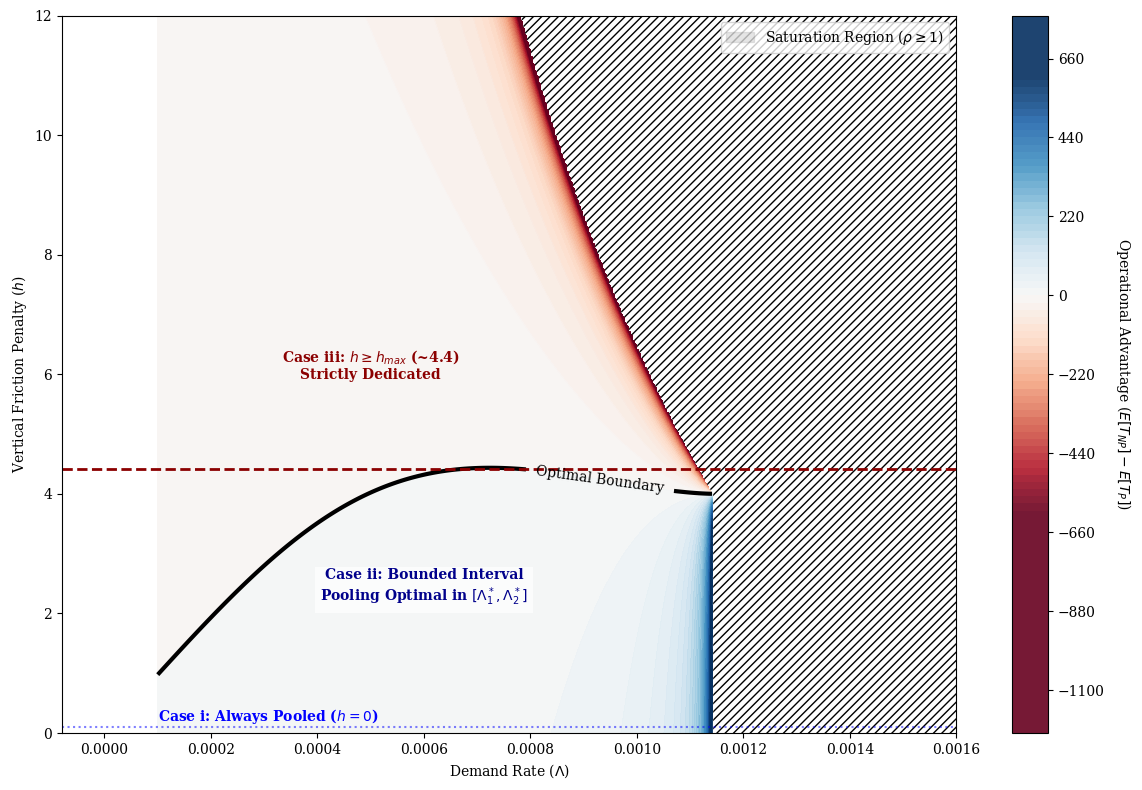

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


plt.rcParams.update({'font.size': 10, 'font.family': 'serif'})

def get_performance_results(Lambda, R, v, p0, h):
    lam_total = Lambda * (R**2)

    # 1. Dedicated (Non-Pooling - NP)
    tau_NP = (4 * R) / (3 * v)
    rho_NP = lam_total * max(p0, 1 - p0) * tau_NP

    # 2. Pooled (P)
    tau_P = (4 * R + 3 * h) / (3 * v)
    rho_P = (lam_total * tau_P) / 2.0

    # Define Stability (Saturation points)
    is_unstable = (rho_NP >= 0.99 or rho_P >= 0.99)

    if is_unstable:
        return np.nan, True

    # Expected Response Times
    t_np = p0 * (tau_NP / (1 - lam_total * p0 * tau_NP)) + \
           (1 - p0) * (tau_NP / (1 - lam_total * (1 - p0) * tau_NP))
    t_p = tau_P / (1 - rho_P**2)

    return (t_np - t_p), False

# Parameters
R_val, v_val, p0_val = 10.0, 1.0, 0.65
lambdas = np.linspace(0.0001, 0.0016, 400)
h_penalties = np.linspace(0, 12, 400)

L, H = np.meshgrid(lambdas, h_penalties)
Z = np.zeros_like(L)
Saturation_Mask = np.zeros_like(L, dtype=bool)

for i in range(len(h_penalties)):
    for j in range(len(lambdas)):
        val, unstable = get_performance_results(lambdas[j], R_val, v_val, p0_val, h_penalties[i])
        Z[i, j] = val
        Saturation_Mask[i, j] = unstable

# Identify h_max for Case iii boundary
# h_max is the highest h where any pooling advantage (Z > 0) exists
advantage_indices = np.where(np.nan_to_num(Z) > 0)
h_max_val = h_penalties[advantage_indices[0].max()] if len(advantage_indices[0]) > 0 else 0

fig, ax = plt.subplots(figsize=(12, 8))

# Diverging color map centered at zero
limit = np.nanmax(np.abs(np.nan_to_num(Z))) * 0.5
norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
cp = ax.contourf(L, H, Z, levels=100, cmap='RdBu', norm=norm, alpha=0.9)
cbar = fig.colorbar(cp)
cbar.set_label('Operational Advantage ($E[T_{NP}] - E[T_P]$)', rotation=270, labelpad=20)

# Optimal Boundary (Black line defining the Interval [Lambda1, Lambda2])
CS = ax.contour(L, H, Z, levels=[0], colors='black', linewidths=3)
ax.clabel(CS, inline=True, fmt='Optimal Boundary', fontsize=10)

# Saturation Points (Hatched Region)
ax.contourf(L, H, Saturation_Mask, levels=[0.5, 1], colors='none', hatches=['////'], alpha=0)
ax.fill_between([0], [0], color='grey', alpha=0.2, hatch='////', label=r'Saturation Region ($\rho \geq 1$)')

# Explicitly marking the 3 Regimes
# Case i: Baseline
ax.axhline(0.1, color='blue', linestyle=':', alpha=0.5)
ax.text(0.0001, 0.2, 'Case i: Always Pooled ($h=0$)', color='blue', fontweight='bold')

# Case ii: The Dome
ax.text(0.0006, h_max_val/2, 'Case ii: Bounded Interval\nPooling Optimal in $[\Lambda_1^*, \Lambda_2^*]$',
        color='darkblue', fontweight='bold', ha='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Case iii: Above h_max
ax.axhline(h_max_val, color='darkred', linestyle='--', linewidth=2)
ax.text(0.0005, h_max_val + 1.5, f'Case iii: $h \geq h_{{max}}$ (~{h_max_val:.1f})\nStrictly Dedicated',
        color='darkred', fontweight='bold', ha='center')

ax.set_xlabel(r'Demand Rate ($\Lambda$)')
ax.set_ylabel(r'Vertical Friction Penalty ($h$)')
#ax.set_title('Regime Map: Architecture Optimality and System Stability')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()